## Цель работы: 
### освоить приёмы классификации с использованием многослойного персеп-трона, изучить влияние его параметров (числа слоёв, числа нейронов, функции активации) на результаты классификации и процесс обучения.

## Задачи: 
### требуется обучить многослойные персептроны решать две разных задачи классификации. Для первой из них следует проанализировать линейную отделимость выборки и по результатам анализа сделать обоснованное предположение о числе скрытых слоёв и нейронов в каждом слое для точной классификации, после чего проверить свои предположения на практике. Для улучшения понимания смысла обучения сетей затем следует визуализировать функции активации нейронов скрытых слоёв.

### Для второй задачи следует проверить влияние увеличения числа слоёв и числа нейронов в слое на длительность одной эпохи обучения, общую длительность обучения и точность на обучающей и тестовой выборках.
### Номера задач классификации определяются по номеру варианта из таблицы 1. Пронумерованные описания выборок для задачи 1 находятся в таблице 2, для задачи 2 — в таблице 3.

### Полные коды всех разработанных методов должны быть предоставлены для проверки; требуемые пояснения могут быть даны в виде комментариев к коду или отдельным документом любого нужного формата.

## Задание 1.
### По номеру варианта определить из таблицы 1 номера выборок для первой и второй задач классификации.
#### Выборка первой задачи: 6
#### Выборки второй задачи: 2, 4, 7

## Задание 2. 
### Определить из таблицы 2 вид выборки — точек двумерного пространства, относящихся к двум классам. Вид плотности их распределения выбирается самостоятельно. Выборки должны покрывать плоскость так, чтобы при визуализации можно было отчётливо увидеть границы классов.

### Описание классов: Первый класс — точки, знак x и y  которых совпадает, второй класс — прочие точки

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

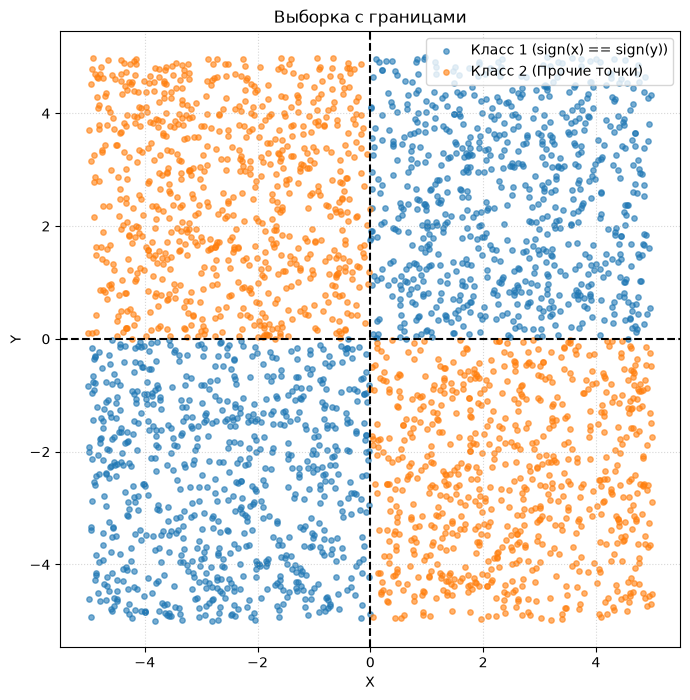

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_quadrant_dataset(n_samples=2000, bounds=(-5, 5), random_state=None):
    """
    Генерирует двумерную выборку точек для двух классов:
    - Класс 0: знаки x и y совпадают (I и III координатные четверти).
    - Класс 1: прочие точки (II и IV координатные четверти).
    
    Параметры:
        n_samples (int): Количество генерируемых точек.
        bounds (tuple): Границы области по оси x и y в формате (min, max).
        random_state (int, optional): Зерно для воспроизводимости.
        
    Возвращает:
        X (np.ndarray): Массив координат точек формы (n_samples, 2).
        y (np.ndarray): Вектор меток классов формы (n_samples,).
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    low, high = bounds
    # Равномерное распределение для качественного покрытия плоскости
    X = np.random.uniform(low=low, high=high, size=(n_samples, 2))
    
    # Исключаем попадание точек ровно на оси x=0 и y=0 для избежания неопределенности
    zero_mask = (X[:, 0] == 0) | (X[:, 1] == 0)
    while np.any(zero_mask):
        X[zero_mask] = np.random.uniform(low=low, high=high, size=(np.sum(zero_mask), 2))
        zero_mask = (X[:, 0] == 0) | (X[:, 1] == 0)
    
    # Произведение x * y > 0 эквивалентно совпадению знаков x и y
    y = np.where(X[:, 0] * X[:, 1] > 0, 0, 1)
    
    return X, y


# Визализация
X, y = generate_quadrant_dataset(n_samples=3000, bounds=(-5, 5), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(
    X[y == 0, 0], X[y == 0, 1], 
    c='tab:blue', alpha=0.6, s=15, label='Класс 1 (sign(x) == sign(y))'
)
plt.scatter(
    X[y == 1, 0], X[y == 1, 1], 
    c='tab:orange', alpha=0.6, s=15, label='Класс 2 (Прочие точки)'
)

# Выделение границ классов
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.title('Выборка с границами')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.axis('equal')
plt.savefig(fname='Sample.png')
plt.show()

1. Определить минимальное число прямых, требуемое для отделения точек одного класса
от другого: 2
2. Определить число связных выпуклых областей, на которые разделён каждый из указан-
ных классов: 2
3. Исходя из полученных результатов, оценить минимальное число слоёв и нейронов в каждом слое, достаточное для успешной классификации:

Прямые $\rightarrow$ Выпуклые области $\rightarrow$ Объединение областей. (3 слоя по два нейрона на скрытые слои и один на выход)

4. Рассчитать значения коэффициентов сети, считая функцию активации ступенчатой.

Примем ступенчатую функцию активации (функцию Хевисайда) в виде:
$$\theta(z) = \begin{cases} 1, & z \ge 0 \\ 0, & z < 0 \end{cases}$$

На вход сети подается вектор координат $\mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}$.

Целевой класс 1 соответствуют областям $xy > 0$ ($y_{\text{out}} = 1$), класс 2 — областям $xy < 0$ ($y_{\text{out}} = 0$).

1. Первый скрытый слой (Разделяющие прямые)
Слой состоит из 2 нейронов, строящих прямые $x = 0$ и $y = 0$:

Нейрон 1 ($h_1^{(1)}$): 

проверяет условие $x \ge 0$

$$z_1^{(1)} = 1 \cdot x + 0 \cdot y + 0 = x \implies h_1^{(1)} = \theta(x)$$

Нейрон 2 ($h_2^{(1)}$): 

проверяет условие $y \ge 0$
$$z_2^{(1)} = 0 \cdot x + 1 \cdot y + 0 = y \implies h_2^{(1)} = \theta(y)$$

$$\mathbf{W}^{(1)} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad \mathbf{b}^{(1)} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$$

2. Второй скрытый слой (Формирование выпуклых областей)

Слой состоит из 2 нейронов, выделяющих I и III четверти (области первого класса) с помощью логической операции И:

Нейрон 1 ($h_1^{(2)}$) — I четверть ($x \ge 0 \land y \ge 0$):

Срабатывает только при $h_1^{(1)} = 1$ и $h_2^{(1)} = 1$:

$$z_1^{(2)} = 1 \cdot h_1^{(1)} + 1 \cdot h_2^{(1)} - 1.5 \implies h_1^{(2)} = \theta(z_1^{(2)})$$

Нейрон 2 ($h_2^{(2)}$) — III четверть ($x < 0 \land y < 0$):

Срабатывает только при $h_1^{(1)} = 0$ и $h_2^{(1)} = 0$:

$$z_2^{(2)} = -1 \cdot h_1^{(1)} - 1 \cdot h_2^{(1)} + 0.5 \implies h_2^{(2)} = \theta(z_2^{(2)})$$

$$\mathbf{W}^{(2)} = \begin{pmatrix} 1 & 1 \\ -1 & -1 \end{pmatrix}, \quad \mathbf{b}^{(2)} = \begin{pmatrix} -1.5 \\ 0.5 \end{pmatrix}$$

3. Выходной слой (Объединение областей)

Выходной нейрон объединяет области первого класса с помощью операции ИЛИ ($h_1^{(2)} = 1 \lor h_2^{(2)} = 1$):

$$z^{\text{out}} = 1 \cdot h_1^{(2)} + 1 \cdot h_2^{(2)} - 0.5 \implies y_{\text{out}} = \theta(z^{\text{out}})$$

$$\mathbf{W}^{(3)} = \begin{pmatrix} 1 & 1 \end{pmatrix}, \quad b^{(3)} = -0.5$$

5. Проверить свои выводы, сгенерировав выборку и подав её на персептрон. При этом требуется получить значения не только выходного слоя, но и скрытых слоёв. Поменять функцию активации, пронаблюдать изменения результатов.

In [3]:
# 1. Задание весов и смещений из пункта 4
W1 = np.array([[1.0, 0.0], 
               [0.0, 1.0]])
b1 = np.array([0.0, 0.0])

W2 = np.array([[ 1.0,  1.0], 
               [-1.0, -1.0]])
b2 = np.array([-1.5, 0.5])

W3 = np.array([[1.0, 1.0]])
b3 = np.array([-0.5])

# Функции активации
def step_act(z):
    return (z >= 0).astype(float)

def sigmoid_act(z, scale=1.0):
    return 1.0 / (1.0 + np.exp(-np.clip(scale * z, -500, 500)))

# Функция прямого прохода с сохранением промежуточных слоев
def forward_pass(X, act_fn):
    # 1-й скрытый слой
    z1 = X @ W1.T + b1
    h1 = act_fn(z1)
    
    # 2-й скрытый слой
    z2 = h1 @ W2.T + b2
    h2 = act_fn(z2)
    
    # Выходной слой
    z3 = h2 @ W3.T + b3
    y_out = act_fn(z3)
    
    return h1, h2, y_out.ravel()

# --- 2. Генерация тестовых точек из 4 четвертей ---
test_points = np.array([
    [ 2.0,  2.0],  # I четверть  (Класс 1)
    [-2.0,  2.0],  # II четверть (Класс 2)
    [-2.0, -2.0],  # III четверть(Класс 1)
    [ 2.0, -2.0]   # IV четверть (Класс 2)
])

h1, h2, y_out = forward_pass(test_points, step_act)

print("--- Проверка контрольных точек (Ступенчатая активация) ---")
for i, pt in enumerate(test_points):
    print(f"Точка {pt}:")
    print(f"  Слой 1 (прямые x, y >= 0) : h1 = {h1[i]}")
    print(f"  Слой 2 (четверти I, III)  : h2 = {h2[i]}")
    print(f"  Выход сети               : y  = {y_out[i]} (Класс {1 if y_out[i] == 1 else 2})\n")

--- Проверка контрольных точек (Ступенчатая активация) ---
Точка [2. 2.]:
  Слой 1 (прямые x, y >= 0) : h1 = [1. 1.]
  Слой 2 (четверти I, III)  : h2 = [1. 0.]
  Выход сети               : y  = 1.0 (Класс 1)

Точка [-2.  2.]:
  Слой 1 (прямые x, y >= 0) : h1 = [0. 1.]
  Слой 2 (четверти I, III)  : h2 = [0. 0.]
  Выход сети               : y  = 0.0 (Класс 2)

Точка [-2. -2.]:
  Слой 1 (прямые x, y >= 0) : h1 = [0. 0.]
  Слой 2 (четверти I, III)  : h2 = [0. 1.]
  Выход сети               : y  = 1.0 (Класс 1)

Точка [ 2. -2.]:
  Слой 1 (прямые x, y >= 0) : h1 = [1. 0.]
  Слой 2 (четверти I, III)  : h2 = [0. 0.]
  Выход сети               : y  = 0.0 (Класс 2)



Заменим дискретную функцию Хевисайда $\theta(z)$ на непрерывную гладкую сигмоиду $\sigma(z)$

$\sigma(z) = \frac{1}{1 + e^{-z}}$

In [4]:
# Прогон тех же точек через сеть с сигмоидой без изменения весов
h1_sig, h2_sig, y_sig = forward_pass(test_points, sigmoid_act)

print("--- Проверка контрольных точек (Сигмоидальная активация) ---")
for i, pt in enumerate(test_points):
    print(f"Точка {pt}:")
    print(f"  Слой 1: h1 = {np.round(h1_sig[i], 3)}")
    print(f"  Слой 2: h2 = {np.round(h2_sig[i], 3)}")
    print(f"  Выход : y  = {np.round(y_sig[i], 3)}")

--- Проверка контрольных точек (Сигмоидальная активация) ---
Точка [2. 2.]:
  Слой 1: h1 = [0.881 0.881]
  Слой 2: h2 = [0.565 0.221]
  Выход : y  = 0.571
Точка [-2.  2.]:
  Слой 1: h1 = [0.119 0.881]
  Слой 2: h2 = [0.378 0.378]
  Выход : y  = 0.563
Точка [-2. -2.]:
  Слой 1: h1 = [0.119 0.119]
  Слой 2: h2 = [0.221 0.565]
  Выход : y  = 0.571
Точка [ 2. -2.]:
  Слой 1: h1 = [0.881 0.119]
  Слой 2: h2 = [0.378 0.378]
  Выход : y  = 0.563


6. Попытаться получить значения коэффициентов путём обучения, сравнить получаемые
результаты с итогами предыдущего пункта. Выявить различия, если они имеются.

In [5]:
from sklearn.neural_network import MLPClassifier

In [6]:
# 1. Генерация обучающей выборки (3000 точек)
np.random.seed(42)
X_train = np.random.uniform(-5, 5, size=(3000, 2))
# Исключаем попадание точно на оси
zero_mask = (X_train[:, 0] == 0) | (X_train[:, 1] == 0)
X_train[zero_mask] += 1e-5

# Класс 1: sign(x) == sign(y) -> y_label = 1; Класс 2: прочие -> y_label = 0
y_train = (X_train[:, 0] * X_train[:, 1] > 0).astype(int)

# 2. Инициализация и обучение MLP с архитектурой (2, 2) и гладкой активацией tanh
# Используем tanh для симметричности относительно нуля
mlp = MLPClassifier(
    hidden_layer_sizes=(2, 2),
    activation='logistic',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
mlp.fit(X_train, y_train)

# 3. Извлечение обученных весов и смещений
weights = mlp.coefs_
biases = mlp.intercepts_

print("--- Обученные коэффициенты сети ---")
print("W1 (Слой 1):\n", np.round(weights[0], 3))
print("b1 (Слой 1):\n", np.round(biases[0], 3))
print("\nW2 (Слой 2):\n", np.round(weights[1], 3))
print("b2 (Слой 2):\n", np.round(biases[1], 3))
print("\nW3 (Выходной слой):\n", np.round(weights[2], 3))
print("b3 (Выходной слой):\n", np.round(biases[2], 3))

print(f"\nТочность на обучающей выборке: {mlp.score(X_train, y_train) * 100:.2f}%")

--- Обученные коэффициенты сети ---
W1 (Слой 1):
 [[-1.2185e+02 -4.0000e-02]
 [ 2.0400e-01  2.9866e+01]]
b1 (Слой 1):
 [-0.276 -0.198]

W2 (Слой 2):
 [[-11.556 -32.648]
 [  9.784  36.998]]
b2 (Слой 2):
 [-3.018 16.359]

W3 (Выходной слой):
 [[ 34.526]
 [-46.303]]
b3 (Выходной слой):
 [23.794]

Точность на обучающей выборке: 100.00%


Алгоритм сам подобрал коэффициенты в случае сигмоиды и вроде инвертировал знаки(проверял x<0 вместо x>0)

7. Оценить влияние числа нейронов на качество результатов. Для этого попробовать обучить сети с числом нейронов в скрытых слоях на единицу меньше или больше ранее рассчитанного и вычислить параметры точности (precision и recall) классификации в зависимости от числа нейронов.

In [7]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

In [16]:
# Генерация сбалансированной обучающей и тестовой выборок
np.random.seed(42)
def generate_data(n_samples=3000):
    X = np.random.uniform(-5, 5, size=(n_samples, 2))
    zero_mask = (X[:, 0] == 0) | (X[:, 1] == 0)
    X[zero_mask] += 1e-5
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    return X, y

X_train, y_train = generate_data(3000)
X_test, y_test = generate_data(1000)

architectures = [
    (1, 1), # Уменьшение в обоих слоях
    (1, 2), # Уменьшение в 1-м слое
    (2, 1), # Уменьшение во 2-м слое
    (2, 2), # Базовая конфигурация
    (3, 2), # Увеличение в 1-м слое
    (2, 3), # Увеличение во 2-м слое
    (3, 3),  # Увеличение в обоих слоях
    (2, 4)
]

results = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='logistic',
        solver='lbfgs',
        max_iter=10000,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    # Расчет Precision и Recall для каждого класса отдельно
    p_c1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    r_c1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    p_c2 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    r_c2 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        'arch': arch,
        'acc': acc,
        'p_c1': p_c1, 'r_c1': r_c1,
        'p_c2': p_c2, 'r_c2': r_c2
    })
df=pd.DataFrame(results)

In [17]:
df.style.highlight_max(
    subset = ['acc', 'p_c1', 'r_c1', 'p_c2', 'r_c2'],
    color = 'green',
    axis = 0
)

,arch,acc,p_c1,r_c1,p_c2,r_c2
0,"(1, 1)",0.483000,0.483000,1.000000,0.000000,0.000000
1,"(1, 2)",0.665000,0.596354,0.948240,0.892241,0.400387
2,"(2, 1)",0.678000,0.615495,0.888199,0.821782,0.481625
3,"(2, 2)",0.999000,1.000000,0.997930,0.998069,1.000000
4,"(3, 2)",0.820000,0.772973,0.888199,0.878652,0.756286
5,"(2, 3)",0.823000,0.847727,0.772257,0.803571,0.870406
6,"(3, 3)",1.000000,1.000000,1.000000,1.000000,1.000000
7,"(2, 4)",1.000000,1.000000,1.000000,1.000000,1.000000


8. Оценить влияние отдельных нейронов на результат. Для этого выбрать какую-либо обученную ранее и достаточно хорошо работающую сеть, после чего вручную обнулить синаптические коэффициенты у нескольких нейронов её предпоследнего слоя (25% и 50% от общего их числа) и измерить параметры точности классификации (precision и recall).
Сделать вывод об избыточности нейросетевой модели.

В качестве архитектуры возьмем 2 нейрона в первом слое и 4 во втором

In [18]:
import copy

In [24]:
# 1. Генерация выборки
np.random.seed(42)
def generate_data(n_samples=3000):
    X = np.random.uniform(-5, 5, size=(n_samples, 2))
    zero_mask = (X[:, 0] == 0) | (X[:, 1] == 0)
    X[zero_mask] += 1e-5
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    return X, y

X_train, y_train = generate_data(3000)
X_test, y_test = generate_data(1000)

# 2. Обучение базовой сети (2, 4)
mlp = MLPClassifier(
    hidden_layer_sizes=(2, 4),
    activation='logistic',
    solver='lbfgs',
    max_iter=10000,
    random_state=42
)
mlp.fit(X_train, y_train)

def evaluate_pruned_model(model, neurons_to_zero=[]):
    """
    Обнуляет синаптические коэффициенты указанных нейронов 2-го слоя
    и вычисляет метрики точности.
    """
    # Создаем копию весов
    W1, W2, W3 = [c.copy() for c in model.coefs_]
    b1, b2, b3 = [b.copy() for b in model.intercepts_]
    
    # Обнуляем входящие и исходящие веса выбранных нейронов во 2-м слое
    for idx in neurons_to_zero:
        W2[:, idx] = 0.0
        b2[idx] = 0.0
        W3[idx, :] = 0.0
        
    # Прямой проход (Forward pass)
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    
    h1 = sigmoid(X_test @ W1 + b1)
    h2 = sigmoid(h1 @ W2 + b2)
    y_prob = sigmoid(h2 @ W3 + b3).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    p_c1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    r_c1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    p_c2 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    r_c2 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    
    return acc, p_c1, r_c1, p_c2, r_c2

# Тестирование разной степени обнуления
metrics_0 = evaluate_pruned_model(mlp, neurons_to_zero=[])
metrics_25 = evaluate_pruned_model(mlp, neurons_to_zero=[0])       # Обнулен 1 нейрон (25%)
metrics_50 = evaluate_pruned_model(mlp, neurons_to_zero=[0, 1])    # Обнулены 2 нейрона (50%)

In [25]:
# 1. Формирование списка строк с распаковкой кортежей метрик (*metrics)
rows = [
    ['0% (Исходная сеть)', '0 из 4', *metrics_0],
    ['25% обнуления', '1 из 4', *metrics_25],
    ['50% обнуления', '2 из 4', *metrics_50],
]

columns = [
    'Степень обнуления',
    'Обнулено нейронов',
    'Accuracy',
    'Precision (Класс 1)',
    'Recall (Класс 1)',
    'Precision (Класс 2)',
    'Recall (Класс 2)',
]

# 2. Создание DataFrame
df_results = pd.DataFrame(rows, columns=columns)

# 3. Стилизация
styled_df = (
    df_results.style.format({
        'Accuracy': '{:.1%}',
        'Precision (Класс 1)': '{:.3f}',
        'Recall (Класс 1)': '{:.3f}',
        'Precision (Класс 2)': '{:.3f}',
        'Recall (Класс 2)': '{:.3f}',
    })
    .highlight_max(
        subset=[
            'Accuracy',
            'Precision (Класс 1)',
            'Recall (Класс 1)',
            'Precision (Класс 2)',
            'Recall (Класс 2)',
        ],
        color='green',
        axis=0,
    )
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
    .hide(axis='index')
)

styled_df

Степень обнуления,Обнулено нейронов,Accuracy,Precision (Класс 1),Recall (Класс 1),Precision (Класс 2),Recall (Класс 2)
0% (Исходная сеть),0 из 4,100.0%,1.000,1.000,1.000,1.000
25% обнуления,1 из 4,73.9%,1.000,0.460,0.665,1.000
50% обнуления,2 из 4,73.9%,1.000,0.460,0.665,1.000


Снижает accuracy на ~25% что может указывать на слепоту одной из четвертей. В частности падает racall для класса 1, что указывает, что слепота либо 1 либо 3 четверти

## Задание 3.
#### Определить по таблице 3 три требуемых типа входных данных. Сгенерировать выборки для каждого из них, после чего объединить любые два из них в один класс, а третий оставить в другом классе. Все распределения вероятности при генерации можно выбирать произвольно. Разделить данные на тестовую и обучающую выборки.

1. Точки внутри шара радиуса 0.5 с центром в (0, -0.5, 0)
4. Точки выше плоскости x + y + z = 3
7. Точки вне параллелепипеда со сторонами (0.5, 1, 1.5)
и центром (-1, 2, 1)

#### Построить графики зависимости длительности обучения от числа нейронов. Построить графики зависимостей параметров точности классификации (precision и recall) от числа нейронов для обучающей и тестовой выборки. Сделать вывод о том, наблюдается ли переобучение или нет в каждом случае, сравнивая результаты для тестовой и обучающей выборки.

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)
n_samples_per_type = 1000

# ==========================================
# 1. Генерация выборок по типам данных
# ==========================================

# Тип 1: Точки внутри сферы R=0.5 с центром (0, -0.5, 0)
def generate_sphere(n_samples):
    points = []
    while len(points) < n_samples:
        # Генерируем точки в описанном кубе и фильтруем по условию сферы
        pts = np.random.uniform(low=[-0.5, -1.0, -0.5], high=[0.5, 0.0, 0.5], size=(n_samples * 2, 3))
        mask = (pts[:, 0]**2 + (pts[:, 1] + 0.5)**2 + pts[:, 2]**2) <= 0.25
        points.extend(pts[mask])
    return np.array(points[:n_samples])

# Тип 2: Точки выше плоскости x + y + z = 3
def generate_above_plane(n_samples):
    points = []
    while len(points) < n_samples:
        pts = np.random.uniform(low=[0, 0, 0], high=[3, 3, 3], size=(n_samples * 2, 3))
        mask = (pts[:, 0] + pts[:, 1] + pts[:, 2]) > 3
        points.extend(pts[mask])
    return np.array(points[:n_samples])

# Тип 3: Точки вне параллелепипеда с центром (-1, 2, 1) и сторонами (0.5, 1.0, 1.5)
def generate_outside_box(n_samples):
    points = []
    while len(points) < n_samples:
        pts = np.random.uniform(low=[-3, 0, -1], high=[1, 4, 3], size=(n_samples * 2, 3))
        mask = (np.abs(pts[:, 0] - (-1)) > 0.25) | \
               (np.abs(pts[:, 1] - 2) > 0.5) | \
               (np.abs(pts[:, 2] - 1) > 0.75)
        points.extend(pts[mask])
    return np.array(points[:n_samples])

X1 = generate_sphere(n_samples_per_type)
X2 = generate_above_plane(n_samples_per_type)
X3 = generate_outside_box(n_samples_per_type)

# ==========================================
# 2. Объединение в 2 класса
# ==========================================
# Класс 0: Объединение Типа 1 и Типа 2
# Класс 1: Тип 3
X_class0 = np.vstack((X1, X2))
y_class0 = np.zeros(len(X_class0), dtype=int)

X_class1 = X3
y_class1 = np.ones(len(X_class1), dtype=int)

X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# ==========================================
# 3. Разделение на обучающую и тестовую выборки
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Размер обучающей выборки X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размер тестовой выборки   X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Размер обучающей выборки X_train: (2400, 3), y_train: (2400,)
Размер тестовой выборки   X_test:  (600, 3), y_test:  (600,)


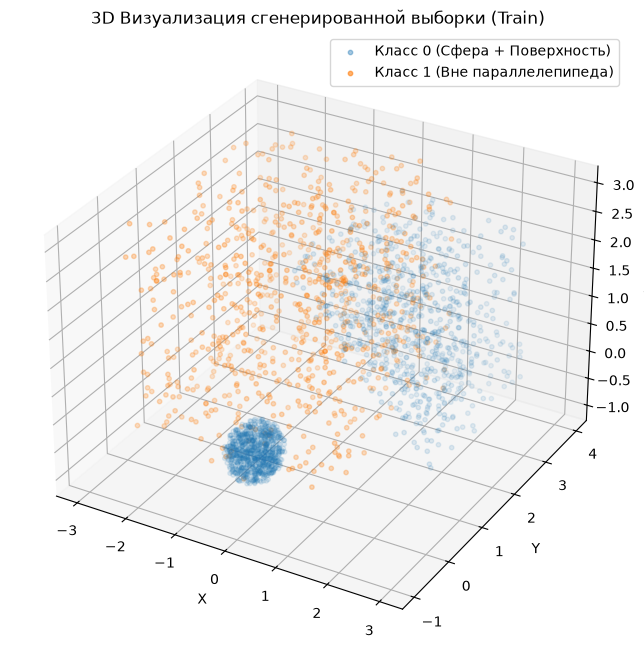

In [30]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Отображение точек обучающей выборки
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], X_train[y_train == 0, 2],
           c='tab:blue', alpha=0.4, s=10, label='Класс 0 (Сфера + Поверхность)')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], X_train[y_train == 1, 2],
           c='tab:orange', alpha=0.6, s=10, label='Класс 1 (Вне параллелепипеда)')

ax.set_title("3D Визуализация сгенерированной выборки (Train)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend(loc='upper right')
plt.savefig(fname='3d viz') 
plt.show()

#### Обучить многослойный персептрон решению данной задачи классификации, подбирая форму сети по визуальным представлениям классов или по иным соображениям. Измерить время обучения 10 сетей, получаемых из исходной последовательным увеличением числа нейронов в первом скрытом слое на 5.

In [32]:
import time

In [36]:
# ==========================================
# 1. Генерация выборки из Задания 3
# ==========================================
np.random.seed(42)
n_samples = 1000

def generate_sphere(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([-0.5, -1.0, -0.5], [0.5, 0.0, 0.5], size=(n*2, 3))
        mask = (raw[:, 0]**2 + (raw[:, 1] + 0.5)**2 + raw[:, 2]**2) <= 0.25
        pts.extend(raw[mask])
    return np.array(pts[:n])

def generate_plane(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([0, 0, 0], [3, 3, 3], size=(n*2, 3))
        mask = (raw[:, 0] + raw[:, 1] + raw[:, 2]) > 3
        pts.extend(raw[mask])
    return np.array(pts[:n])

def generate_box_outside(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([-3, 0, -1], [1, 4, 3], size=(n*2, 3))
        mask = (np.abs(raw[:, 0] - (-1)) > 0.25) | \
               (np.abs(raw[:, 1] - 2) > 0.5) | \
               (np.abs(raw[:, 2] - 1) > 0.75)
        pts.extend(raw[mask])
    return np.array(pts[:n])

# Класс 0: Сфера + Плоскость; Класс 1: Вне параллелепипеда
X0 = np.vstack((generate_sphere(n_samples), generate_plane(n_samples)))
X1 = generate_box_outside(n_samples)

X = np.vstack((X0, X1))
y = np.hstack((np.zeros(len(X0), dtype=int), np.ones(len(X1), dtype=int)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. Обучение 10 сетей с увеличением N1 на +5
# ==========================================
N2 = 8  # Постоянное число нейронов во 2-м скрытом слое
neurons_layer1 = [5 + 5 * i for i in range(10)]  # [5, 10, 15, ..., 50]

records = []

for idx, n1 in enumerate(neurons_layer1, start=1):
    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, N2),
        activation='logistic',
        solver='lbfgs',
        max_iter=25000,
        random_state=42
    )
    
    # Измерение времени обучения
    start_time = time.perf_counter()
    mlp.fit(X_train, y_train)
    elapsed_time = time.perf_counter() - start_time
    
    # Оценка качества
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    
    records.append({
        '№ сети': idx,
        'Архитектура': f'({n1}, {N2})',
        'Нейронов в 1-м слое': n1,
        'Время обучения (сек)': elapsed_time,
        'Итерации': mlp.n_iter_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })

df_experiment = pd.DataFrame(records)

# ==========================================
# 3. Вывод таблицы результатов
# ==========================================
styled_table = (
    df_experiment.style
    .format({
        'Время обучения (сек)': '{:.4f}',
        'Accuracy': '{:.1%}',
        'Precision': '{:.3f}',
        'Recall': '{:.3f}'
    })
    .highlight_min(subset=['Время обучения (сек)'], color='green')
    .highlight_max(subset=['Accuracy'], color='green')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
    .hide(axis='index')
)

styled_table

№ сети,Архитектура,Нейронов в 1-м слое,Время обучения (сек),Итерации,Accuracy,Precision,Recall
1,"(5, 8)",5,2.3104,2214,96.5%,0.969,0.953
2,"(10, 8)",10,0.7616,598,96.0%,0.965,0.945
3,"(15, 8)",15,2.6212,1838,97.0%,0.972,0.960
4,"(20, 8)",20,1.2064,751,97.5%,0.979,0.965
5,"(25, 8)",25,19.1185,10818,95.3%,0.947,0.949
6,"(30, 8)",30,3.1631,1619,96.5%,0.965,0.956
7,"(35, 8)",35,2.5087,1222,96.7%,0.964,0.961
8,"(40, 8)",40,5.0745,2398,95.8%,0.954,0.953
9,"(45, 8)",45,11.6334,4529,94.7%,0.938,0.943
10,"(50, 8)",50,5.7501,2311,96.2%,0.958,0.955


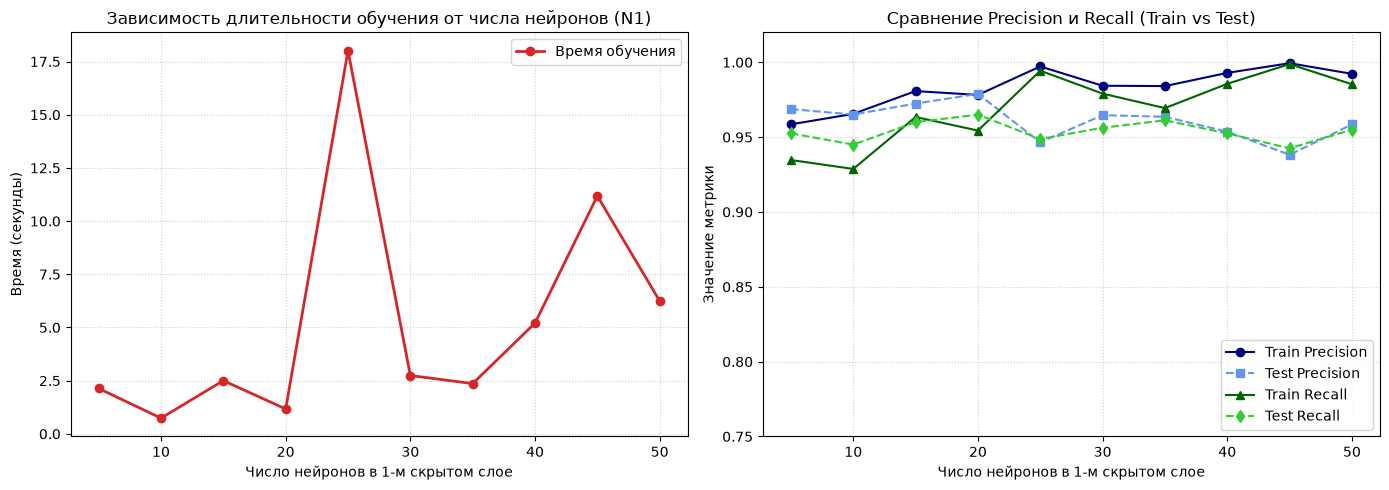

In [39]:
# ==========================================
# 1. Генерация выборки из Задания 3
# ==========================================
np.random.seed(42)
n_samples = 1000

def generate_sphere(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([-0.5, -1.0, -0.5], [0.5, 0.0, 0.5], size=(n*2, 3))
        mask = (raw[:, 0]**2 + (raw[:, 1] + 0.5)**2 + raw[:, 2]**2) <= 0.25
        pts.extend(raw[mask])
    return np.array(pts[:n])

def generate_plane(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([0, 0, 0], [3, 3, 3], size=(n*2, 3))
        mask = (raw[:, 0] + raw[:, 1] + raw[:, 2]) > 3
        pts.extend(raw[mask])
    return np.array(pts[:n])

def generate_box_outside(n):
    pts = []
    while len(pts) < n:
        raw = np.random.uniform([-3, 0, -1], [1, 4, 3], size=(n*2, 3))
        mask = (np.abs(raw[:, 0] - (-1)) > 0.25) | \
               (np.abs(raw[:, 1] - 2) > 0.5) | \
               (np.abs(raw[:, 2] - 1) > 0.75)
        pts.extend(raw[mask])
    return np.array(pts[:n])

# Класс 0: Сфера + Плоскость; Класс 1: Вне параллелепипеда
X0 = np.vstack((generate_sphere(n_samples), generate_plane(n_samples)))
X1 = generate_box_outside(n_samples)

X = np.vstack((X0, X1))
y = np.hstack((np.zeros(len(X0), dtype=int), np.ones(len(X1), dtype=int)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. Обучение 10 сетей и сбор метрик
# ==========================================
N2 = 8  # Фиксированное число нейронов во 2-м слое
neurons_layer1 = [5 + 5 * i for i in range(10)]  # [5, 10, 15, ..., 50]

records = []

for n1 in neurons_layer1:
    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, N2),
        activation='logistic',
        solver='lbfgs',
        max_iter=25000,
        random_state=42
    )
    
    # Замер времени
    t0 = time.perf_counter()
    mlp.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    
    # Предсказания
    y_tr_pred = mlp.predict(X_train)
    y_te_pred = mlp.predict(X_test)
    
    # Метрики для ОБУЧАЮЩЕЙ выборки
    tr_prec = precision_score(y_train, y_tr_pred, average='macro', zero_division=0)
    tr_rec = recall_score(y_train, y_tr_pred, average='macro', zero_division=0)
    
    # Метрики для ТЕСТОВОЙ выборки
    te_prec = precision_score(y_test, y_te_pred, average='macro', zero_division=0)
    te_rec = recall_score(y_test, y_te_pred, average='macro', zero_division=0)
    
    records.append({
        'N1': n1,
        'Time': elapsed,
        'Train_Prec': tr_prec,
        'Train_Rec': tr_rec,
        'Test_Prec': te_prec,
        'Test_Rec': te_rec
    })

df = pd.DataFrame(records)

# ==========================================
# 3. Построение графиков
# ==========================================
plt.figure(figsize=(14, 5))

# График 1: Длительность обучения от N1
plt.subplot(1, 2, 1)
plt.plot(df['N1'], df['Time'], marker='o', color='tab:red', linewidth=2, label='Время обучения')
plt.title('Зависимость длительности обучения от числа нейронов (N1)')
plt.xlabel('Число нейронов в 1-м скрытом слое')
plt.ylabel('Время (секунды)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# График 2: Precision и Recall (Train vs Test)
plt.subplot(1, 2, 2)
plt.plot(df['N1'], df['Train_Prec'], marker='o', color='navy', linestyle='-', label='Train Precision')
plt.plot(df['N1'], df['Test_Prec'], marker='s', color='cornflowerblue', linestyle='--', label='Test Precision')
plt.plot(df['N1'], df['Train_Rec'], marker='^', color='darkgreen', linestyle='-', label='Train Recall')
plt.plot(df['N1'], df['Test_Rec'], marker='d', color='limegreen', linestyle='--', label='Test Recall')

plt.title('Сравнение Precision и Recall (Train vs Test)')
plt.xlabel('Число нейронов в 1-м скрытом слое')
plt.ylabel('Значение метрики')
plt.ylim(0.75, 1.02)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Начиная примерно с 21 нейронов начинается переобучение

Контрольные вопросы
1. Как оценить требуемую конфигурацию сети при линейно отделимых выборках?
Линейная отделимость означает, что классы в их пространстве разделяются единой гиперплоскостью вида 

$$\mathbf{w}^T \mathbf{x} + b = 0$$

2. Как повлияло на качество изменение функции активации нейронов?
При изменении функции активации при тех же весах качество значительно упало. После подбора весов получили 100% точность на трейне

3. Как повлияло увеличение числа нейронов на качество? на длительность обучения?
При увеличении числа нейронов растет количество времени на обучение и качество до определенного значения. После чего происходит переобучение при добавлении нейронов

4. Как проявляется переобучение сети при её обучении? Как оно влияет на результат клас-
сификации тестовой выборки?
Переобучение сети проявилось в том, что было затрачено больше всего времени на ее обучение, но при этом метрики ухудшились. Соответственно модель учится предсказывать треин выборку из-за чего хуже классифицирует на тесте
